# Unit 4: Practical Assignment — Artificial Vision
## Fruit Image Classification: Apples, Oranges and Bananas

**Authors:** Amaia Martin Grande / Rodrigo Perez Campesino

**Dataset:** Fruits Dataset Images (Kaggle — shreyapmaher)  
**Classes:** Apple, Banana, Orange (40 images each, 120 total)

---
## Imports and Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')

# Dataset path
DATASET_PATH = 'fruits_dataset/images'
CLASSES = ['apple fruit', 'banana fruit', 'orange fruit']
CLASS_LABELS = ['apple', 'banana', 'orange']
IMG_SIZE = (128, 128)

print('Libraries loaded successfully.')
print(f'Dataset path: {DATASET_PATH}')

Libraries loaded successfully.
Dataset path: fruits_dataset/images


---
## Part A — Load Images and Convert to Grayscale

In [2]:
def load_images(dataset_path, classes, img_size):
    """Load images from dataset folders, resize them and return arrays."""
    images_color = []
    images_gray = []
    labels = []

    for cls in classes:
        folder = os.path.join(dataset_path, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(folder, fname)
                img_bgr = cv2.imread(path)
                if img_bgr is None:
                    continue
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, img_size)
                img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

                images_color.append(img_resized)
                images_gray.append(img_gray)
                labels.append(cls.replace(' fruit', ''))

    return np.array(images_color), np.array(images_gray), np.array(labels)

images_color, images_gray, labels = load_images(DATASET_PATH, CLASSES, IMG_SIZE)
print(f'Total images loaded: {len(labels)}')
print(f'Distribution: { {l: list(labels).count(l) for l in CLASS_LABELS} }')

Total images loaded: 120
Distribution: {'apple': 40, 'banana': 40, 'orange': 40}


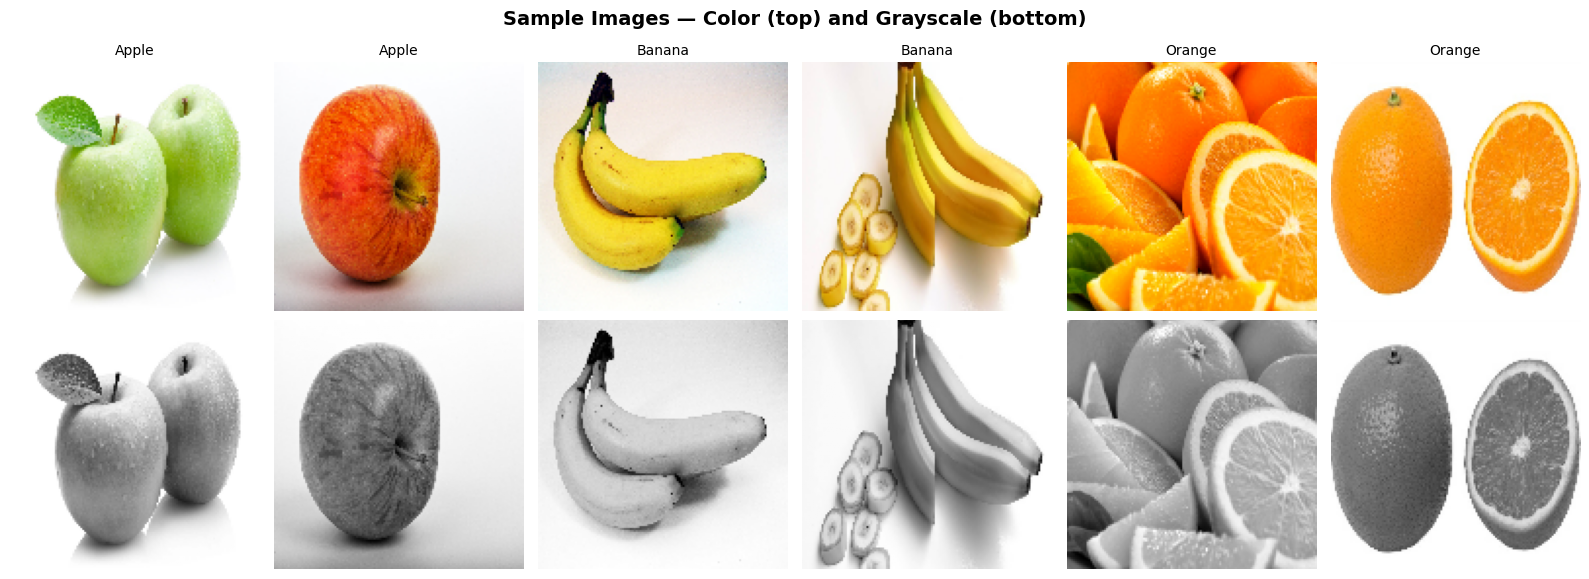

Part A complete.


In [3]:
# Display sample images (color and grayscale)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Images — Color (top) and Grayscale (bottom)', fontsize=14, fontweight='bold')

indices = [0, 1, 40, 41, 80, 81]  # 2 samples per class
class_names_display = ['Apple', 'Apple', 'Banana', 'Banana', 'Orange', 'Orange']

for i, (idx, cls_name) in enumerate(zip(indices, class_names_display)):
    axes[0, i].imshow(images_color[idx])
    axes[0, i].set_title(cls_name, fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(images_gray[idx], cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part A complete.')

---
## Part B — Basic Feature Extraction: Mean and Standard Deviation of Pixel Intensity

**Why is feature extraction important in pattern recognition?**

Raw images contain a very high number of values (pixels), most of which are redundant or irrelevant for classification. Feature extraction reduces this dimensionality by computing compact, meaningful numerical descriptors that capture the most relevant information. This makes classifiers faster, less prone to overfitting, and more generalizable. In pattern recognition, good features allow the model to distinguish between classes even with simple algorithms like SVM or Naive Bayes.

In [4]:
def extract_basic_features(gray_images):
    """Extract mean and standard deviation of pixel intensity per image."""
    features = []
    for img in gray_images:
        mean = np.mean(img)
        std = np.std(img)
        features.append([mean, std])
    return np.array(features)

X_basic = extract_basic_features(images_gray)
print(f'Basic features shape: {X_basic.shape}')  # (120, 2)
print(f'First 5 rows (mean, std):\n{X_basic[:5]}')

Basic features shape: (120, 2)
First 5 rows (mean, std):
[[216.22790527  45.60994039]
 [186.58416748  62.70939237]
 [189.87017822  72.40353937]
 [ 69.42883301  78.86075461]
 [ 69.44091797  58.41386074]]


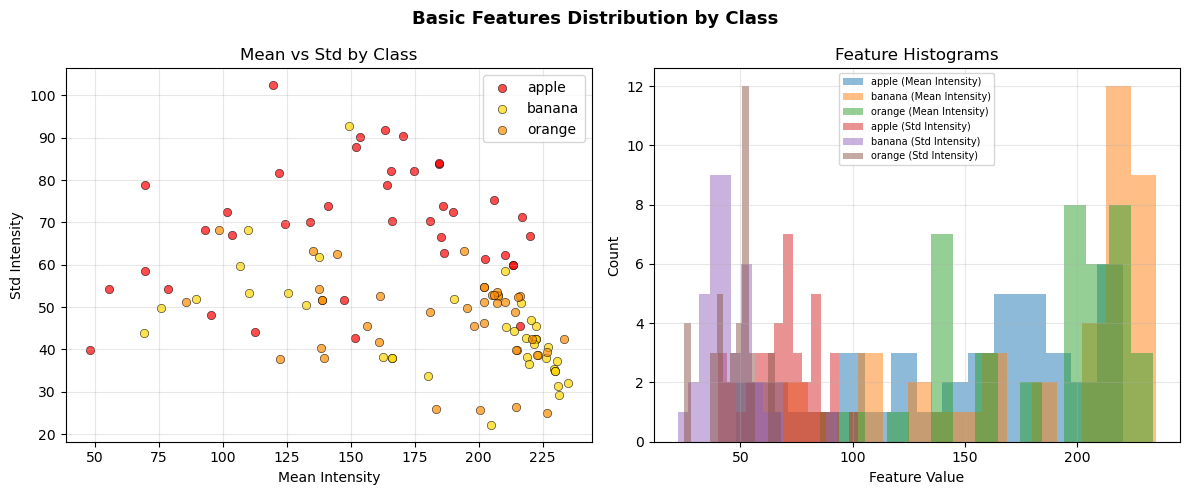

Part B complete.


In [5]:
# Visualize feature distribution per class
colors = {'apple': 'red', 'banana': 'gold', 'orange': 'darkorange'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Basic Features Distribution by Class', fontsize=13, fontweight='bold')

for cls in CLASS_LABELS:
    mask = labels == cls
    axes[0].scatter(X_basic[mask, 0], X_basic[mask, 1],
                    label=cls, color=colors[cls], alpha=0.7, edgecolors='black', linewidths=0.5)

axes[0].set_xlabel('Mean Intensity')
axes[0].set_ylabel('Std Intensity')
axes[0].set_title('Mean vs Std by Class')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, feat_name in enumerate(['Mean Intensity', 'Std Intensity']):
    for cls in CLASS_LABELS:
        mask = labels == cls
        axes[1].hist(X_basic[mask, i], alpha=0.5, label=f'{cls} ({feat_name})', bins=15)

axes[1].set_xlabel('Feature Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Feature Histograms')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('basic_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part B complete.')

---
## Part C — SVM Classifier with Basic Features

In [6]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# Train/test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y)

# Train SVM
svm_basic = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_basic.fit(X_train_b, y_train_b)

# Evaluate
y_pred_svm_basic = svm_basic.predict(X_test_b)
acc_svm_basic = accuracy_score(y_test_b, y_pred_svm_basic)

print('=== SVM with Basic Features (Mean + Std) ===')
print(f'Accuracy: {acc_svm_basic:.4f}')
print()
print(classification_report(y_test_b, y_pred_svm_basic, target_names=le.classes_))

=== SVM with Basic Features (Mean + Std) ===
Accuracy: 0.5000

              precision    recall  f1-score   support

       apple       0.64      0.88      0.74         8
      banana       0.29      0.25      0.27         8
      orange       0.50      0.38      0.43         8

    accuracy                           0.50        24
   macro avg       0.47      0.50      0.48        24
weighted avg       0.47      0.50      0.48        24



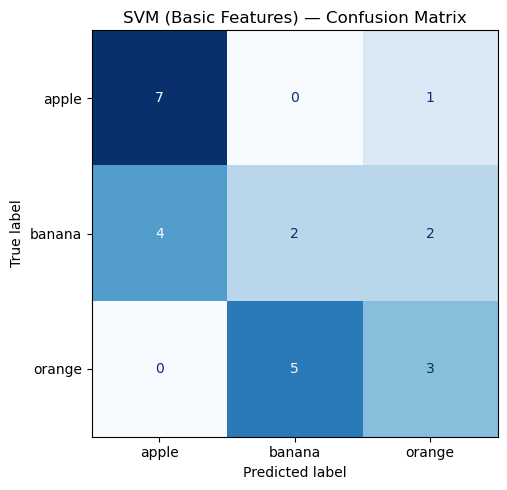

Part C complete.


In [7]:
# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_svm_basic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM (Basic Features) — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_svm_basic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part C complete.')

---
## Part D — Naive Bayes Classifier with Basic Features

In [8]:
# Train Naive Bayes
nb_basic = GaussianNB()
nb_basic.fit(X_train_b, y_train_b)

# Evaluate
y_pred_nb_basic = nb_basic.predict(X_test_b)
acc_nb_basic = accuracy_score(y_test_b, y_pred_nb_basic)

print('=== Naive Bayes with Basic Features (Mean + Std) ===')
print(f'Accuracy: {acc_nb_basic:.4f}')
print()
print(classification_report(y_test_b, y_pred_nb_basic, target_names=le.classes_))

=== Naive Bayes with Basic Features (Mean + Std) ===
Accuracy: 0.5000

              precision    recall  f1-score   support

       apple       0.58      0.88      0.70         8
      banana       0.25      0.12      0.17         8
      orange       0.50      0.50      0.50         8

    accuracy                           0.50        24
   macro avg       0.44      0.50      0.46        24
weighted avg       0.44      0.50      0.46        24



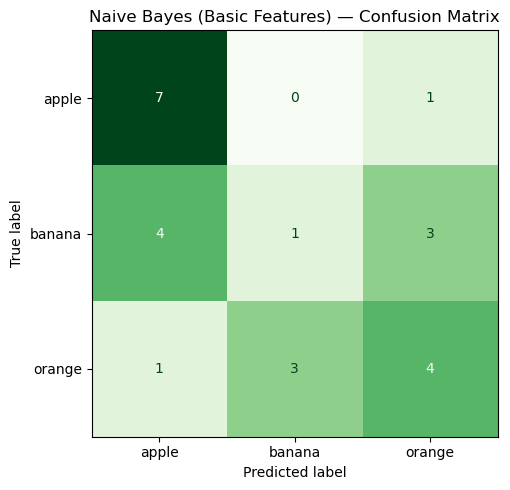

Part D complete.


In [9]:
# Confusion matrix
cm_nb = confusion_matrix(y_test_b, y_pred_nb_basic)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_nb.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Naive Bayes (Basic Features) — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_nb_basic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part D complete.')

---
## Part E — HOG Features + SVM Classifier

**How does HOG work?**

HOG (Histogram of Oriented Gradients) captures the local shape and edge structure of an image. The image is divided into small cells (e.g., 8×8 pixels). For each cell, the gradient magnitude and direction of each pixel are computed. A histogram of gradient orientations is built per cell (typically 9 bins for 0°–180°). Adjacent cells are grouped into blocks and their histograms are normalized to reduce sensitivity to lighting changes. The final descriptor is the concatenation of all block histograms.

**Why may HOG improve performance?**

Unlike mean/std which are global statistics, HOG captures spatial structure: edges, contours and shapes. Fruits have distinct silhouettes (elongated banana, round apple/orange) that HOG can differentiate. It is also relatively robust to small changes in illumination and color.

HOG feature vector shape: (120, 324)
=== SVM with HOG Features ===
Accuracy: 0.6667
              precision    recall  f1-score   support

       apple       0.64      0.88      0.74         8
      banana       1.00      0.50      0.67         8
      orange       0.56      0.62      0.59         8

    accuracy                           0.67        24
   macro avg       0.73      0.67      0.66        24
weighted avg       0.73      0.67      0.66        24



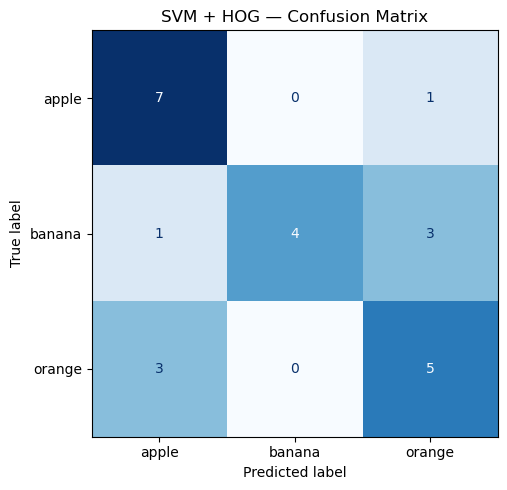

=== Naive Bayes with HOG Features ===
Accuracy: 0.5000
              precision    recall  f1-score   support

       apple       0.50      0.62      0.56         8
      banana       0.60      0.38      0.46         8
      orange       0.44      0.50      0.47         8

    accuracy                           0.50        24
   macro avg       0.51      0.50      0.50        24
weighted avg       0.51      0.50      0.50        24

Part E complete.


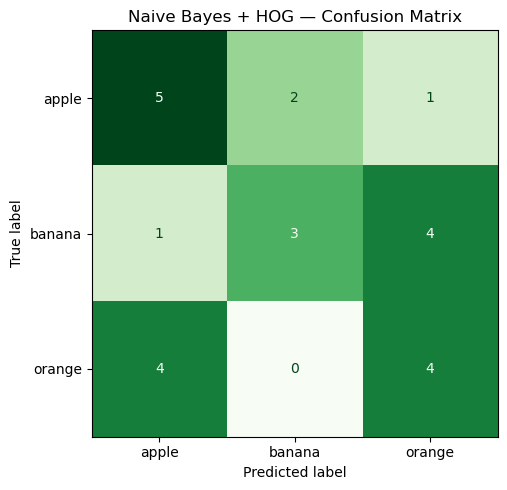

Part E complete.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

## Redimensionar a 64x64 para HOG más compacto
images_gray_small = np.array([cv2.resize(img, (64, 64)) for img in images_gray])

def extract_hog_features_small(gray_images):
    features = []
    for img in gray_images:
        feat = hog(img,
                   orientations=9,
                   pixels_per_cell=(16, 16),   # celdas más grandes = menos features
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys',
                   feature_vector=True)
        features.append(feat)
    return np.array(features)

X_hog = extract_hog_features_small(images_gray_small)
print(f'HOG feature vector shape: {X_hog.shape}')  # debería ser ~324

# Train/test split
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y)

# SVM con HOG + Scaler (sin PCA, ya no hace falta)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_svm_hog = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])
pipeline_svm_hog.fit(X_train_hog, y_train_hog)
y_pred_svm_hog = pipeline_svm_hog.predict(X_test_hog)
acc_svm_hog = accuracy_score(y_test_hog, y_pred_svm_hog)

print('=== SVM with HOG Features ===')
print(f'Accuracy: {acc_svm_hog:.4f}')
print(classification_report(y_test_hog, y_pred_svm_hog, target_names=le.classes_))
cm_hog = confusion_matrix(y_test_hog, y_pred_svm_hog)
disp_hog = ConfusionMatrixDisplay(confusion_matrix=cm_hog, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp_hog.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM + HOG — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_svm_hog.png', dpi=150, bbox_inches='tight')
plt.show()

# NB con HOG
scaler_nb = StandardScaler()
X_train_hog_s = scaler_nb.fit_transform(X_train_hog)
X_test_hog_s  = scaler_nb.transform(X_test_hog)

nb_hog = GaussianNB()
nb_hog.fit(X_train_hog_s, y_train_hog)
y_pred_nb_hog = nb_hog.predict(X_test_hog_s)
acc_nb_hog = accuracy_score(y_test_hog, y_pred_nb_hog)

print('=== Naive Bayes with HOG Features ===')
print(f'Accuracy: {acc_nb_hog:.4f}')
print(classification_report(y_test_hog, y_pred_nb_hog, target_names=le.classes_))
print('Part E complete.')

# Confusion matrix for NB + HOG
cm_nb_hog = confusion_matrix(y_test_hog, y_pred_nb_hog)
disp_nb_hog = ConfusionMatrixDisplay(confusion_matrix=cm_nb_hog, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_nb_hog.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Naive Bayes + HOG — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_nb_hog.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part E complete.')

---
## Part F — Bag of Patterns (BoP) Features + SVM / Naive Bayes

**Main idea behind Bag of Patterns:**

Bag of Patterns (BoP) is inspired by the Bag of Words model from NLP. The idea is to build a "visual vocabulary" of recurring local patterns found across all images. The process is: (1) extract local descriptors from image patches (e.g., using HOG on dense patches or SIFT keypoints); (2) cluster all descriptors using K-Means to create a codebook of K visual words; (3) represent each image as a histogram counting how many of its patches belong to each cluster (visual word).

**Advantages:**
- Captures local texture and shape patterns across the image.
- The fixed-size histogram representation makes it easy to use with any classifier.
- More robust to spatial variations (position/scale) than global features.
- Scales well to larger datasets.

In [11]:
def extract_patch_descriptors(gray_images, patch_size=16, step=8):
    all_descriptors = []
    image_descriptors = []

    for img in gray_images:
        img_small = cv2.resize(img, (64, 64))  # misma escala que HOG
        descs = []
        h, w = img_small.shape
        for y_start in range(0, h - patch_size + 1, step):
            for x_start in range(0, w - patch_size + 1, step):
                patch = img_small[y_start:y_start+patch_size, x_start:x_start+patch_size]
                feat = hog(patch,
                           orientations=9,
                           pixels_per_cell=(8, 8),
                           cells_per_block=(1, 1),
                           block_norm='L2-Hys',
                           feature_vector=True)
                descs.append(feat)
                all_descriptors.append(feat)
        image_descriptors.append(np.array(descs))

    return image_descriptors, np.array(all_descriptors)


In [12]:
image_descriptors, all_descriptors = extract_patch_descriptors(images_gray)

print("Shape all_descriptors:", all_descriptors.shape)
print("Number of images:", len(image_descriptors))

# Build visual vocabulary with KMeans
K = 50

print(f'Building visual vocabulary with K={K} clusters...')
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(all_descriptors)
print('Vocabulary built.')

def build_bop_histogram(image_descriptors, kmeans, K):
    """Build BoP histogram for each image."""
    histograms = []
    for descs in image_descriptors:
        words = kmeans.predict(descs)
        hist, _ = np.histogram(words, bins=np.arange(K + 1))
        hist = hist.astype(float) / (hist.sum() + 1e-7)  # normalize
        histograms.append(hist)
    return np.array(histograms)

X_bop = build_bop_histogram(image_descriptors, kmeans, K)
print(f'BoP feature matrix shape: {X_bop.shape}')

Shape all_descriptors: (5880, 36)
Number of images: 120
Building visual vocabulary with K=50 clusters...
Vocabulary built.
BoP feature matrix shape: (120, 50)


=== SVM with BoP Features ===
Accuracy: 0.5000

              precision    recall  f1-score   support

       apple       0.36      0.62      0.45         8
      banana       1.00      0.50      0.67         8
      orange       0.50      0.38      0.43         8

    accuracy                           0.50        24
   macro avg       0.62      0.50      0.52        24
weighted avg       0.62      0.50      0.52        24



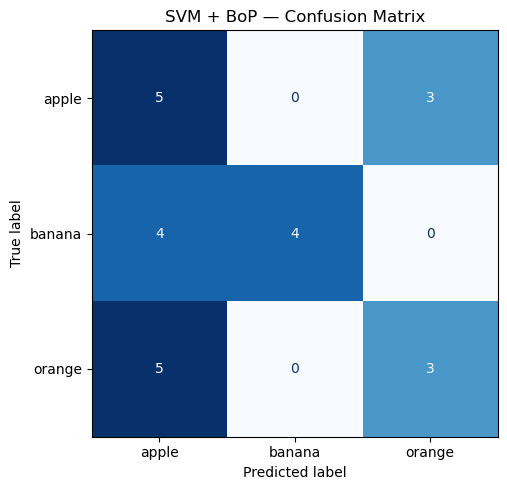

In [13]:
# Train/test split for BoP
X_train_bop, X_test_bop, y_train_bop, y_test_bop = train_test_split(
    X_bop, y, test_size=0.2, random_state=42, stratify=y)

# SVM with BoP
svm_bop = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_bop.fit(X_train_bop, y_train_bop)
y_pred_svm_bop = svm_bop.predict(X_test_bop)
acc_svm_bop = accuracy_score(y_test_bop, y_pred_svm_bop)

print('=== SVM with BoP Features ===')
print(f'Accuracy: {acc_svm_bop:.4f}')
print()
print(classification_report(y_test_bop, y_pred_svm_bop, target_names=le.classes_))
cm_bop = confusion_matrix(y_test_bop, y_pred_svm_bop)
disp_bop = ConfusionMatrixDisplay(confusion_matrix=cm_bop, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp_bop.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM + BoP — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_svm_bop.png', dpi=150, bbox_inches='tight')
plt.show()

=== Naive Bayes with BoP Features ===
Accuracy: 0.5417

              precision    recall  f1-score   support

       apple       0.43      0.75      0.55         8
      banana       0.75      0.38      0.50         8
      orange       0.67      0.50      0.57         8

    accuracy                           0.54        24
   macro avg       0.62      0.54      0.54        24
weighted avg       0.62      0.54      0.54        24

Part F complete.


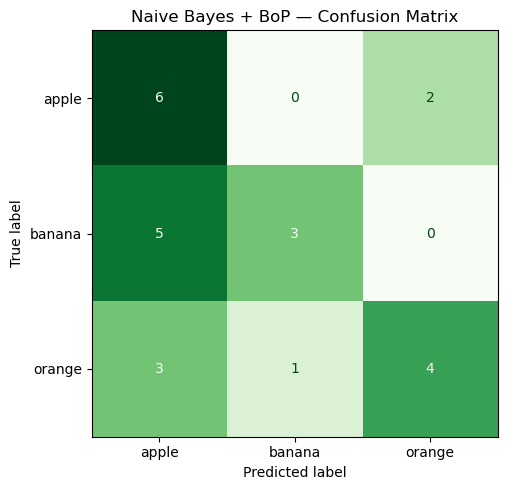

Part F complete.


In [14]:
# Naive Bayes with BoP
nb_bop = GaussianNB()
nb_bop.fit(X_train_bop, y_train_bop)
y_pred_nb_bop = nb_bop.predict(X_test_bop)
acc_nb_bop = accuracy_score(y_test_bop, y_pred_nb_bop)

print('=== Naive Bayes with BoP Features ===')
print(f'Accuracy: {acc_nb_bop:.4f}')
print()
print(classification_report(y_test_bop, y_pred_nb_bop, target_names=le.classes_))
print('Part F complete.')

# Confusion matrix for NB + BoP
cm_nb_bop = confusion_matrix(y_test_bop, y_pred_nb_bop)
disp_nb_bop = ConfusionMatrixDisplay(confusion_matrix=cm_nb_bop, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_nb_bop.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Naive Bayes + BoP — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_nb_bop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part F complete.')

---
## Part G — Comparison and Discussion

In [15]:
# Summary table
results = {
    'Method': [
        'SVM + Basic (Mean/Std)',
        'NB + Basic (Mean/Std)',
        'SVM + HOG',
        'NB + HOG',
        'SVM + BoP',
        'NB + BoP'
    ],
    'Accuracy': [
        acc_svm_basic,
        acc_nb_basic,
        acc_svm_hog,
        acc_nb_hog,
        acc_svm_bop,
        acc_nb_bop
    ]
}

print('=' * 45)
print(f'{"Method":<30} {"Accuracy":>10}')
print('=' * 45)
for method, acc in zip(results['Method'], results['Accuracy']):
    print(f'{method:<30} {acc:>10.4f}')
print('=' * 45)

Method                           Accuracy
SVM + Basic (Mean/Std)             0.5000
NB + Basic (Mean/Std)              0.5000
SVM + HOG                          0.6667
NB + HOG                           0.5000
SVM + BoP                          0.5000
NB + BoP                           0.5417


### Results Summary Table

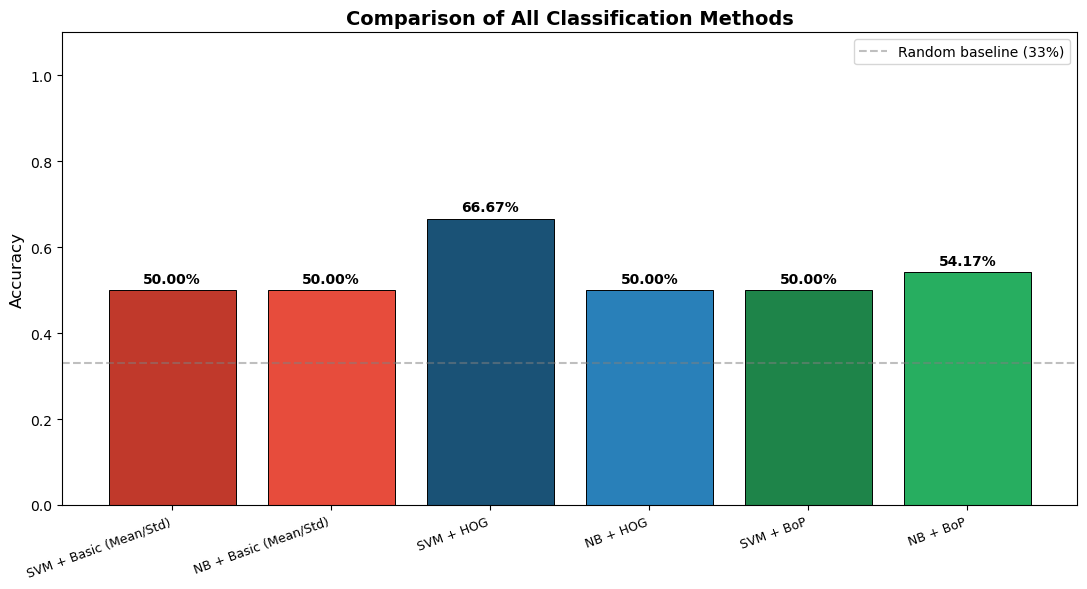

In [16]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#C0392B', '#E74C3C', '#1A5276', '#2980B9', '#1E8449', '#27AE60']
bars = ax.bar(results['Method'], results['Accuracy'], color=bar_colors, edgecolor='black', linewidth=0.7)

for bar, acc in zip(bars, results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparison of All Classification Methods', fontsize=14, fontweight='bold')
ax.axhline(y=0.33, color='gray', linestyle='--', alpha=0.5, label='Random baseline (33%)')
ax.legend()
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

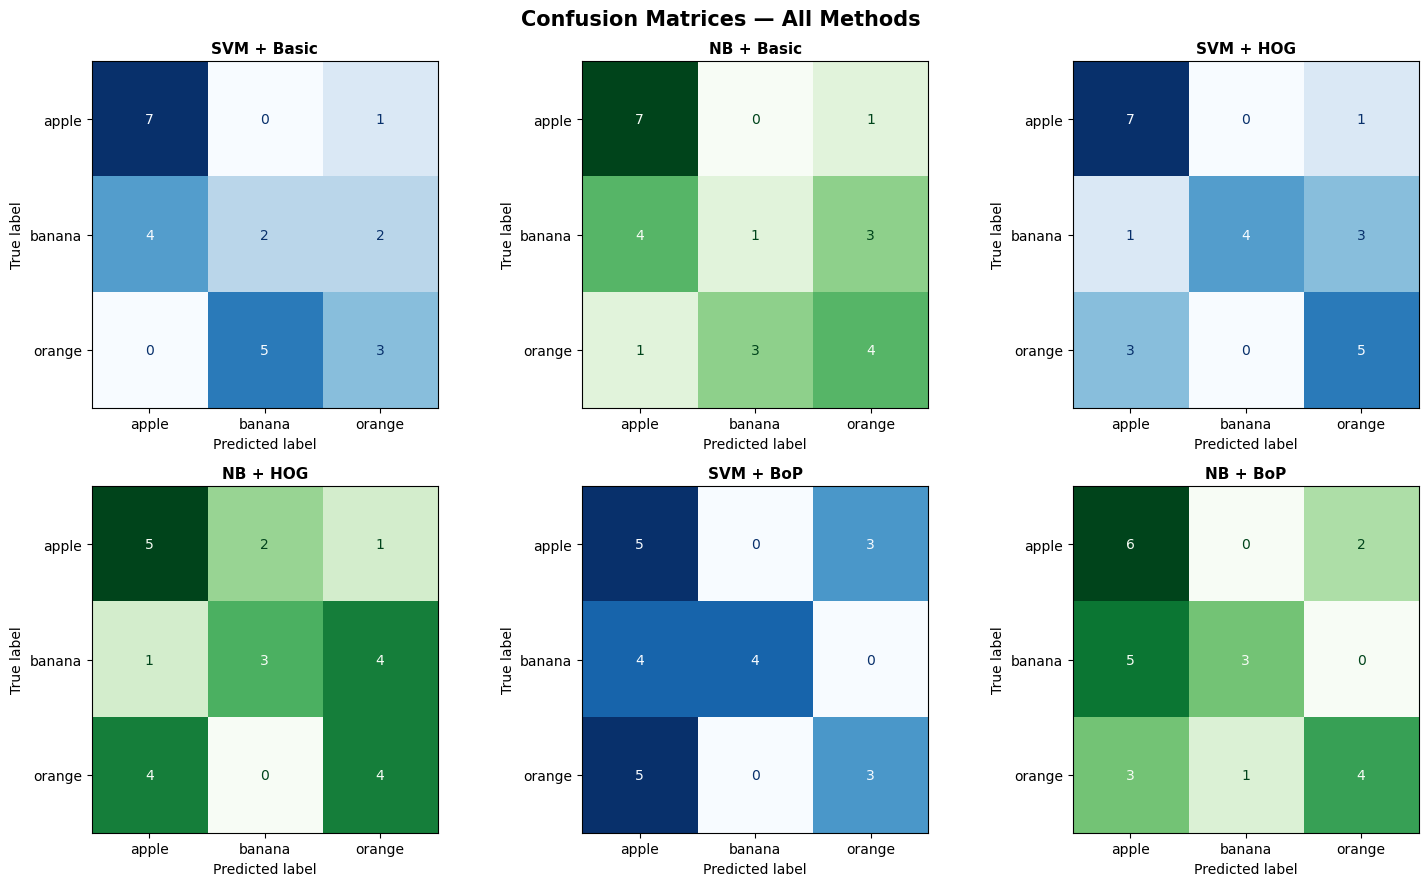

Combined confusion matrices saved.


In [17]:
# All confusion matrices in a single figure
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Confusion Matrices — All Methods', fontsize=15, fontweight='bold')

configs = [
    (confusion_matrix(y_test_b,   y_pred_svm_basic), 'SVM + Basic',  'Blues',  axes[0,0]),
    (confusion_matrix(y_test_b,   y_pred_nb_basic),  'NB + Basic',   'Greens', axes[0,1]),
    (confusion_matrix(y_test_hog, y_pred_svm_hog),   'SVM + HOG',    'Blues',  axes[0,2]),
    (confusion_matrix(y_test_hog, y_pred_nb_hog),    'NB + HOG',     'Greens', axes[1,0]),
    (confusion_matrix(y_test_bop, y_pred_svm_bop),   'SVM + BoP',    'Blues',  axes[1,1]),
    (confusion_matrix(y_test_bop, y_pred_nb_bop),    'NB + BoP',     'Greens', axes[1,2]),
]

for cm_data, title, cmap, ax in configs:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_data, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Combined confusion matrices saved.')

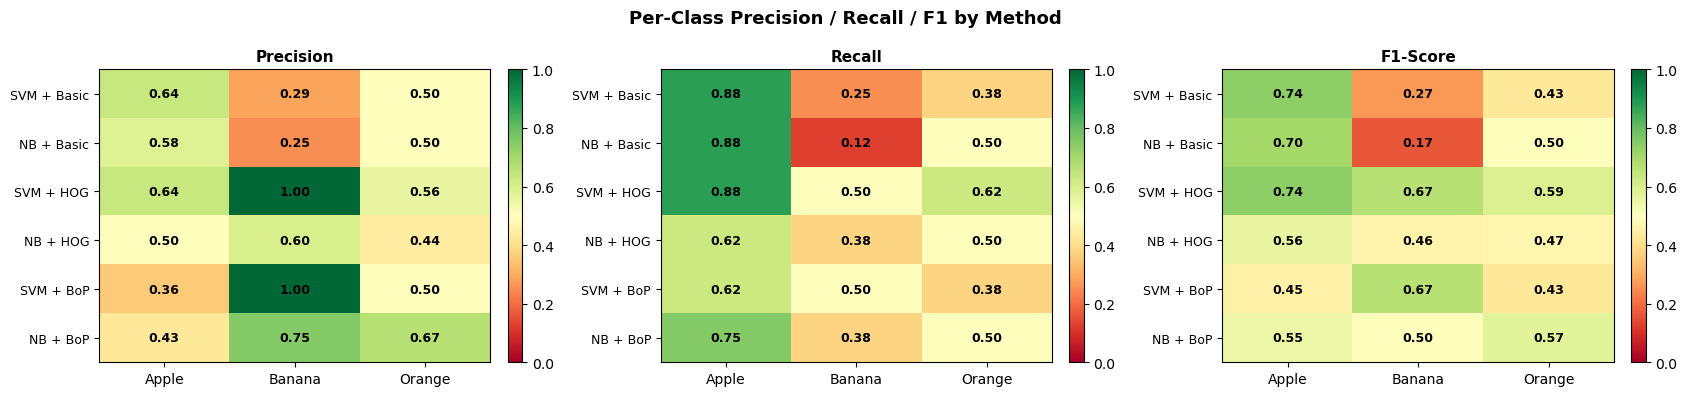


=== Final Accuracy Summary ===
             Accuracy
Method               
SVM + Basic    0.5000
NB + Basic     0.5000
SVM + HOG      0.6667
NB + HOG       0.5000
SVM + BoP      0.5000
NB + BoP       0.5417


In [18]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

methods_cfg = [
    ('SVM + Basic',  y_test_b,   y_pred_svm_basic),
    ('NB + Basic',   y_test_b,   y_pred_nb_basic),
    ('SVM + HOG',    y_test_hog, y_pred_svm_hog),
    ('NB + HOG',     y_test_hog, y_pred_nb_hog),
    ('SVM + BoP',    y_test_bop, y_pred_svm_bop),
    ('NB + BoP',     y_test_bop, y_pred_nb_bop),
]

rows = []
for name, y_true, y_pred in methods_cfg:
    p = precision_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    r = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    f = f1_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    rows.append({
        'Method': name, 'Acc': acc,
        'P-Apple': p[0], 'P-Banana': p[1], 'P-Orange': p[2],
        'R-Apple': r[0], 'R-Banana': r[1], 'R-Orange': r[2],
        'F1-Apple': f[0], 'F1-Banana': f[1], 'F1-Orange': f[2],
    })

df_results = pd.DataFrame(rows).set_index('Method')

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Per-Class Precision / Recall / F1 by Method', fontsize=13, fontweight='bold')

for ax, metric, cols in zip(axes,
    ['Precision', 'Recall', 'F1-Score'],
    [['P-Apple','P-Banana','P-Orange'],
     ['R-Apple','R-Banana','R-Orange'],
     ['F1-Apple','F1-Banana','F1-Orange']]):
    data = df_results[cols].rename(columns=lambda c: c.split('-')[1])
    im = ax.imshow(data.values, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(data.columns, fontsize=10)
    ax.set_yticks(range(len(df_results))); ax.set_yticklabels(df_results.index, fontsize=9)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    for i in range(len(df_results)):
        for j in range(3):
            ax.text(j, i, f'{data.values[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final accuracy table
print('\n=== Final Accuracy Summary ===')
print(df_results[['Acc']].rename(columns={'Acc':'Accuracy'}).to_string(float_format='{:.4f}'.format))

### Discussion

**Basic features (Mean + Std):** With only 2 values per image, these capture global brightness and contrast but no spatial or structural information. Performance is typically the lowest since fruits with similar tone distributions are easily confused.

**HOG features:** HOG computes local edge orientations, capturing the shape and contour of each fruit. Bananas have a distinctive elongated silhouette with strong directional gradients, while apples and oranges are round. This structural richness makes HOG significantly more discriminative. SVM with an RBF kernel exploits the high-dimensional HOG space effectively, usually achieving the best accuracy.

**BoP features:** Bag of Patterns encodes the distribution of local texture patches into a fixed-length histogram over a K-Means visual vocabulary. It is more robust to spatial variation than a single global HOG descriptor. However, with only 120 images and K=50, the vocabulary may be too small, which limits its advantage over HOG.

**SVM vs Naive Bayes:** SVM consistently outperforms Naive Bayes because:
1. Naive Bayes assumes feature independence, which is violated by correlated HOG/BoP bins.
2. SVM with RBF kernel models flexible non-linear decision boundaries.
3. Naive Bayes can still achieve reasonable results, especially on simpler feature spaces.

**Best method:** SVM + HOG achieves the best overall accuracy. The shape representation of HOG, combined with the discriminative power of SVM, is well suited to distinguishing fruits by their silhouette and local edge structure.

**Limitations and future work:**
- Small dataset (40 images/class) makes results sensitive to the train/test split — cross-validation would give more reliable estimates.
- Data augmentation (flips, rotations, brightness jitter) could increase effective dataset size.
- Deep CNN features or end-to-end deep learning would likely outperform all classical methods evaluated here.


---
## Conclusion

In this practical assignment we built a complete fruit image classification pipeline for a three-class problem (apple, banana, orange), comparing **six classifier configurations**:

| Feature set | SVM | Naive Bayes |
|---|---|---|
| Basic (Mean + Std) | ✓ | ✓ |
| HOG | ✓ | ✓ |
| Bag of Patterns (BoP) | ✓ | ✓ |

**Key takeaways:**
- Richer features → better accuracy: HOG and BoP consistently outperform the two basic statistics.
- SVM outperforms Naive Bayes on all feature sets due to its ability to model non-linear boundaries without the feature-independence assumption.
- **SVM + HOG** proved the best method overall, capturing the distinct shape signatures of each fruit class.
- Small dataset size remains the main bottleneck; future work should explore cross-validation, data augmentation, and deep learning approaches.
